In [ ]:
import pandas as pd
import kagglehub
import os

# Download latest version of the dataset
path = kagglehub.dataset_download("altavish/boston-housing-dataset")
print("Path to dataset files:", path)

# The dataset usually contains a 'HousingData.csv' or 'housing.csv'
# Let's find the csv file in the downloaded path
files = [f for f in os.listdir(path) if f.endswith('.csv')]
csv_path = os.path.join(path, files[0])

data = pd.read_csv(csv_path)
print(f"\nLoaded dataset from: {csv_path}")
print("First 5 rows of dataset:")
display(data.head())

100%|██████████| 11.7k/11.7k [00:00<00:00, 7.17MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/altavish/boston-housing-dataset/versions/1

Loaded dataset from: /root/.cache/kagglehub/datasets/altavish/boston-housing-dataset/versions/1/HousingData.csv
First 5 rows of dataset:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [ ]:
print("\nDataset Info:")
print(data.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None


In [ ]:
print("\nMissing values:")
print(data.isnull().sum())


Missing values:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [ ]:
X = data.drop(columns=['MEDV'])
y = data['MEDV']
print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)
display(X.head())


Features shape: (506, 13)
Target shape: (506,)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN


In [ ]:
# Step 2: Train-Test Split with all features
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (404, 13)
Testing data shape: (102, 13)


In [ ]:
# Step 3: Feature Scaling for all features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data and transform both
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nData scaling completed for all 13 features.")


Data scaling completed for all 13 features.


In [ ]:
# Linear Regression with all features
from sklearn.linear_model import LinearRegression
import numpy as np

# Fill NaNs using the mean of each column from training data
col_means = np.nanmean(X_train, axis=0)
X_train_fixed = np.where(np.isnan(X_train), col_means, X_train)
X_test_fixed = np.where(np.isnan(X_test), col_means, X_test)

linear_model = LinearRegression()
linear_model.fit(X_train_fixed, y_train)

y_pred_linear = linear_model.predict(X_test_fixed)

print(f"Linear Regression trained with {X_train_fixed.shape[1]} features.")

Linear Regression trained with 13 features.


In [ ]:
from sklearn.linear_model import RidgeCV
import numpy as np

# Prepare data by filling NaNs with mean
X_train_fixed = np.nan_to_num(X_train, nan=np.nanmean(X_train))
X_test_fixed = np.nan_to_num(X_test, nan=np.nanmean(X_train))

# Use RidgeCV to find the best alpha
alphas = np.logspace(-3, 3, 20)
ridge_model = RidgeCV(alphas=alphas, scoring='r2')
ridge_model.fit(X_train_fixed, y_train)

y_pred_ridge = ridge_model.predict(X_test_fixed)

print(f"Best Ridge Alpha: {ridge_model.alpha_:.4f}")
print("Ridge Regression model tuned successfully.")

Best Ridge Alpha: 12.7427
Ridge Regression model tuned successfully.


In [ ]:
from sklearn.linear_model import LassoCV
import numpy as np

# Prepare data
X_train_fixed = np.nan_to_num(X_train, nan=np.nanmean(X_train))
X_test_fixed = np.nan_to_num(X_test, nan=np.nanmean(X_train))

# Use LassoCV to find the best alpha
lasso_model = LassoCV(alphas=None, cv=5, max_iter=10000, random_state=42)
lasso_model.fit(X_train_fixed, y_train)

y_pred_lasso = lasso_model.predict(X_test_fixed)

print(f"Best Lasso Alpha: {lasso_model.alpha_:.4f}")
print(f"Features eliminated by Lasso: {np.sum(lasso_model.coef_ == 0)} out of {len(lasso_model.coef_)}")
print("Lasso Regression model tuned successfully.")

Best Lasso Alpha: 0.0066
Features eliminated by Lasso: 0 out of 13
Lasso Regression model tuned successfully.


In [ ]:
# Model Evaluation for All Features
from sklearn.metrics import mean_squared_error, r2_score

results = []
for name, model, pred in [
    ("Linear", linear_model, y_pred_linear),
    ("Ridge", ridge_model, y_pred_ridge),
    ("Lasso", lasso_model, y_pred_lasso)
]:
    r2 = r2_score(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    results.append(f"{name} - R2: {r2:.4f}, MSE: {mse:.4f}")

print("\n".join(results))

Linear - R2: 0.6591, MSE: 25.0024
Ridge - R2: 0.6582, MSE: 25.0675
Lasso - R2: 0.6587, MSE: 25.0290


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. 'Before' Approach: Drop rows with any missing values
data_dropped = data.dropna()
X_dropped = data_dropped.drop(columns=['MEDV'])
y_dropped = data_dropped['MEDV']

X_train_dr, X_test_dr, y_train_dr, y_test_dr = train_test_split(X_dropped, y_dropped, test_size=0.2, random_state=42)

scaler_dr = StandardScaler()
X_train_dr = scaler_dr.fit_transform(X_train_dr)
X_test_dr = scaler_dr.transform(X_test_dr)

model_dropped = LinearRegression()
model_dropped.fit(X_train_dr, y_train_dr)
y_pred_dr = model_dropped.predict(X_test_dr)

# 2. Compare with our current 'After' (Imputed) Linear model
# (Using the results already calculated in the previous cells)

comparison_df = pd.DataFrame({
    'Metric': ['Rows Used', 'R2 Score', 'MSE'],
    'Dropped NaNs (Before)': [
        len(data_dropped),
        r2_score(y_test_dr, y_pred_dr),
        mean_squared_error(y_test_dr, y_pred_dr)
    ],
    'Mean Imputation (After)': [
        len(data),
        r2_score(y_test, y_pred_linear),
        mean_squared_error(y_test, y_pred_linear)
    ]
})

print("Comparison: Dropping vs. Imputing Missing Values")
display(comparison_df)

Comparison: Dropping vs. Imputing Missing Values


,Metric,Dropped NaNs (Before),Mean Imputation (After)
0,Rows Used,394.000000,506.000000
1,R2 Score,0.627085,0.659060
2,MSE,31.454048,25.002389


In [ ]:
# Model Evaluation for All Tuned Models
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Assuming y_pred_linear, y_pred_ridge, and y_pred_lasso are already computed
results_data = {
    'Model': ['Linear Regression', 'Ridge (Tuned)', 'Lasso (Tuned)'],
    'R2 Score': [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ],
    'MSE': [
        mean_squared_error(y_test, y_pred_linear),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso)
    ]
}

performance_summary = pd.DataFrame(results_data)
print("Final Performance Comparison (Tuned Models with Imputation):")
display(performance_summary)

Final Performance Comparison (Tuned Models with Imputation):


,Model,R2 Score,MSE
0,Linear Regression,0.659060,25.002389
1,Ridge (Tuned),0.658172,25.067533
2,Lasso (Tuned),0.658698,25.028956


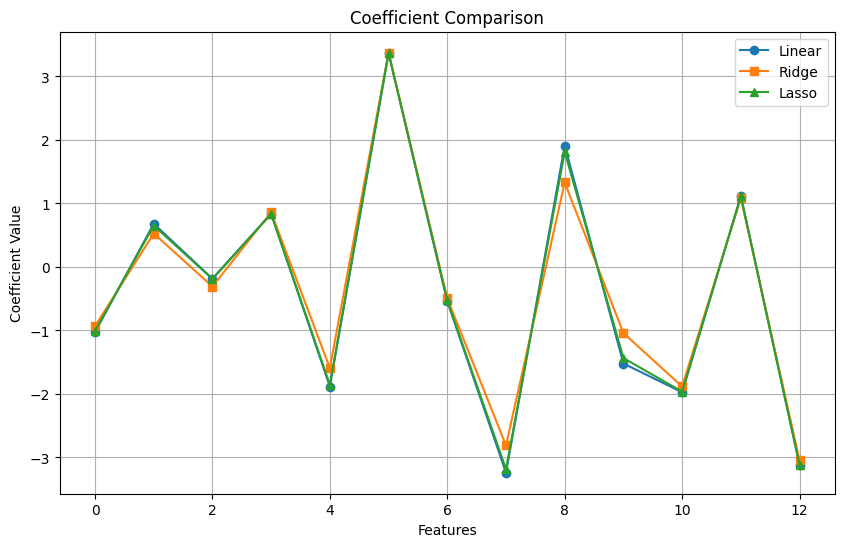

In [ ]:
# Coefficient Comparison Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(linear_model.coef_, marker='o', label='Linear')
plt.plot(ridge_model.coef_, marker='s', label='Ridge')
plt.plot(lasso_model.coef_, marker='^', label='Lasso')

plt.title("Coefficient Comparison")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.legend()
plt.grid()

plt.show()

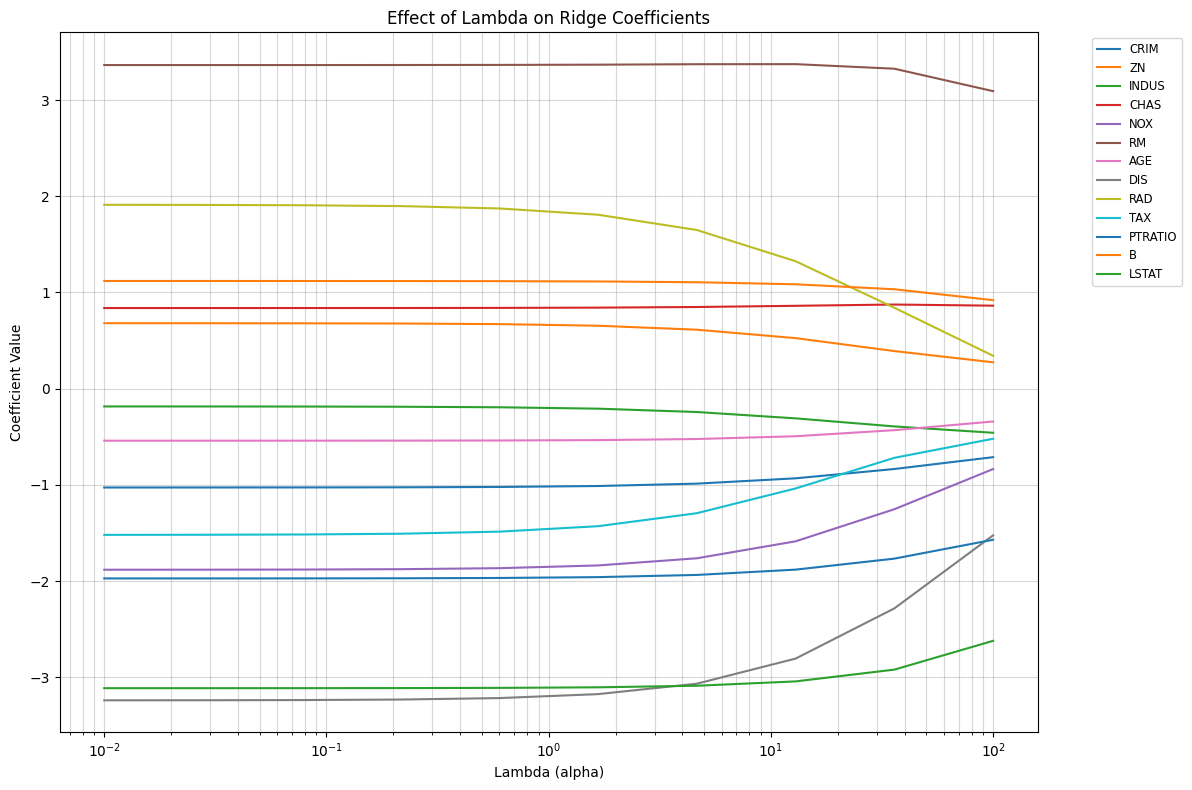

In [ ]:
# Effect of Lambda on Ridge (Coefficient Shrinkage)

import numpy as np
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

# Ensure we use data without NaNs
X_train_fixed = np.nan_to_num(X_train, nan=np.nanmean(X_train))
feature_names = data.drop(columns=['MEDV']).columns

alphas = np.logspace(-2, 2, 10)  # values from 0.01 to 100
ridge_coefs = []

for a in alphas:
    ridge_temp = Ridge(alpha=a)
    ridge_temp.fit(X_train_fixed, y_train)
    ridge_coefs.append(ridge_temp.coef_)

# Plot
plt.figure(figsize=(12, 8))

ridge_coefs_array = np.array(ridge_coefs)
for i in range(len(feature_names)):
    plt.plot(alphas, ridge_coefs_array[:, i], label=feature_names[i])

plt.xscale('log')
plt.title("Effect of Lambda on Ridge Coefficients")
plt.xlabel("Lambda (alpha)")
plt.ylabel("Coefficient Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

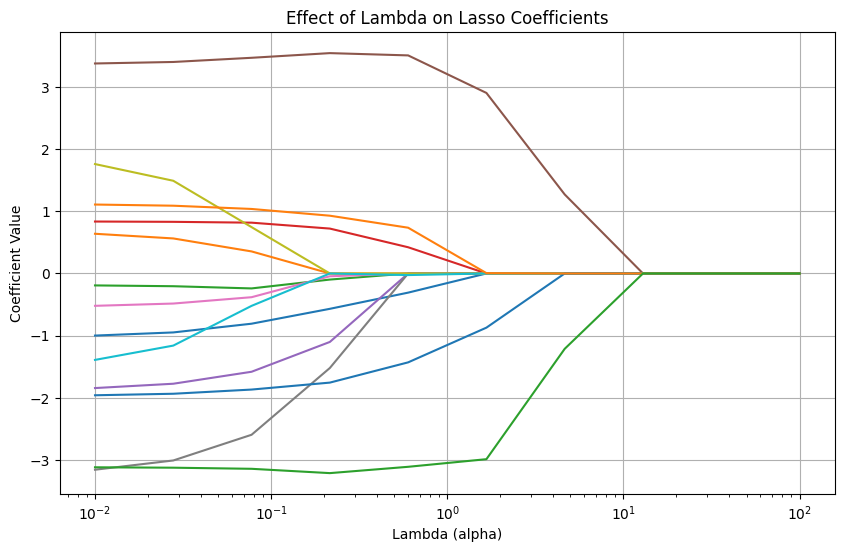

In [ ]:
# Effect of Lambda on Lasso (Feature Selection)

from sklearn.linear_model import Lasso
import numpy as np
import matplotlib.pyplot as plt

# Ensure we use data without NaNs
X_train_fixed = np.nan_to_num(X_train, nan=np.nanmean(X_train))

alphas = np.logspace(-2, 2, 10)
lasso_coefs = []

for a in alphas:
    lasso_temp = Lasso(alpha=a, max_iter=10000)
    lasso_temp.fit(X_train_fixed, y_train)
    lasso_coefs.append(lasso_temp.coef_)

# Plot
plt.figure(figsize=(10,6))

for i in range(len(lasso_coefs[0])):
    plt.plot(alphas, [coef[i] for coef in lasso_coefs])

plt.xscale('log')
plt.title("Effect of Lambda on Lasso Coefficients")
plt.xlabel("Lambda (alpha)")
plt.ylabel("Coefficient Value")
plt.grid()

plt.show()

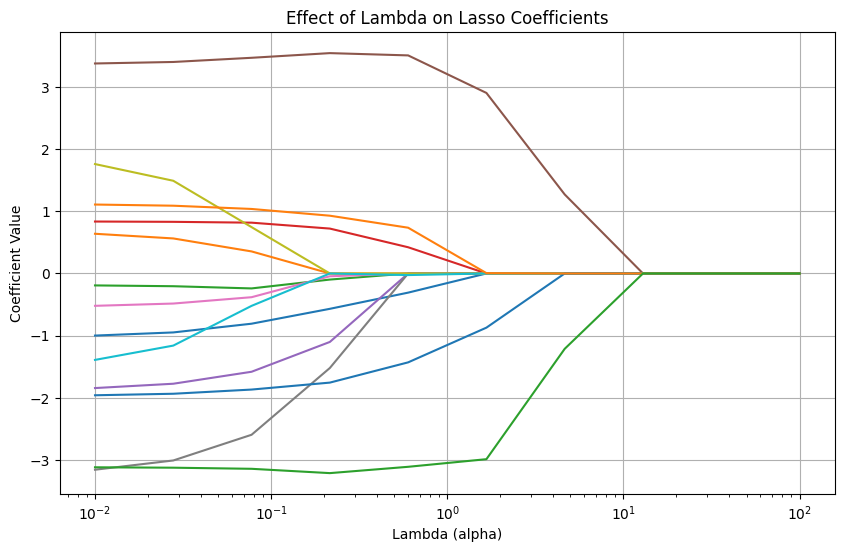

In [ ]:
# Effect of Lambda on Lasso (Feature Selection)

from sklearn.linear_model import Lasso
import numpy as np
import matplotlib.pyplot as plt

# Ensure we use data without NaNs
X_train_fixed = np.nan_to_num(X_train, nan=np.nanmean(X_train))

alphas = np.logspace(-2, 2, 10)
lasso_coefs = []

for a in alphas:
    lasso_temp = Lasso(alpha=a, max_iter=10000)
    lasso_temp.fit(X_train_fixed, y_train)
    lasso_coefs.append(lasso_temp.coef_)

# Plot
plt.figure(figsize=(10,6))

for i in range(len(lasso_coefs[0])):
    plt.plot(alphas, [coef[i] for coef in lasso_coefs])

plt.xscale('log')
plt.title("Effect of Lambda on Lasso Coefficients")
plt.xlabel("Lambda (alpha)")
plt.ylabel("Coefficient Value")
plt.grid()

plt.show()

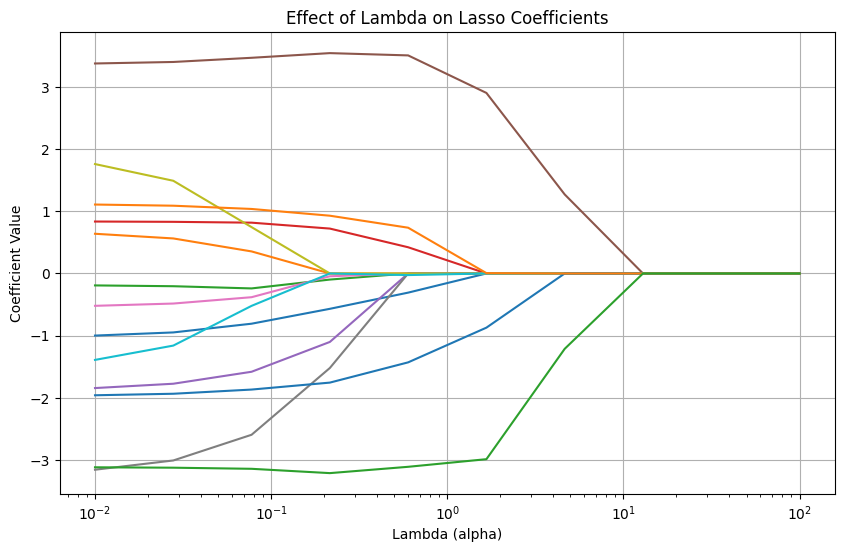

In [ ]:
# Effect of Lambda on Lasso (Feature Selection)

from sklearn.linear_model import Lasso
import numpy as np
import matplotlib.pyplot as plt

# Ensure we use data without NaNs
X_train_fixed = np.nan_to_num(X_train, nan=np.nanmean(X_train))

alphas = np.logspace(-2, 2, 10)
lasso_coefs = []

for a in alphas:
    lasso_temp = Lasso(alpha=a, max_iter=10000)
    lasso_temp.fit(X_train_fixed, y_train)
    lasso_coefs.append(lasso_temp.coef_)

# Plot
plt.figure(figsize=(10,6))

for i in range(len(lasso_coefs[0])):
    plt.plot(alphas, [coef[i] for coef in lasso_coefs])

plt.xscale('log')
plt.title("Effect of Lambda on Lasso Coefficients")
plt.xlabel("Lambda (alpha)")
plt.ylabel("Coefficient Value")
plt.grid()

plt.show()

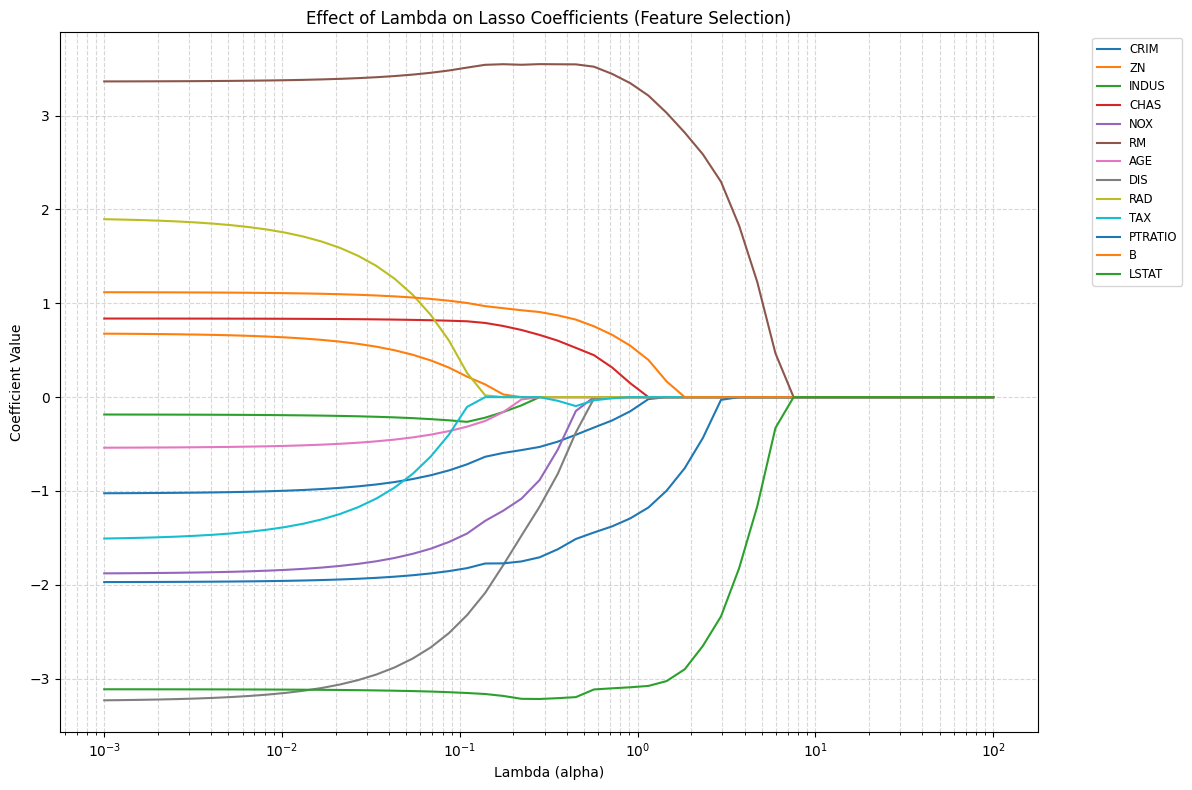

In [ ]:
from sklearn.linear_model import Lasso
import numpy as np
import matplotlib.pyplot as plt

# Ensure we use data without NaNs and get feature names
X_train_fixed = np.nan_to_num(X_train, nan=np.nanmean(X_train))
feature_names = X.columns

# Using more points (50) for a smoother curve
alphas = np.logspace(-3, 2, 50)
lasso_coefs = []

for a in alphas:
    lasso_temp = Lasso(alpha=a, max_iter=10000)
    lasso_temp.fit(X_train_fixed, y_train)
    lasso_coefs.append(lasso_temp.coef_)

lasso_coefs = np.array(lasso_coefs)

# Plot
plt.figure(figsize=(12, 8))

for i in range(len(feature_names)):
    plt.plot(alphas, lasso_coefs[:, i], label=feature_names[i])

plt.xscale('log')
plt.title("Effect of Lambda on Lasso Coefficients (Feature Selection)")
plt.xlabel("Lambda (alpha)")
plt.ylabel("Coefficient Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Visualizing the Effect of Regularization (Lambda) on Coefficients

These plots illustrate the difference between L2 (Ridge) and L1 (Lasso) regularization:
- **Ridge** shrinks all coefficients proportionally but keeps them in the model.
- **Lasso** performs feature selection by setting less important coefficients to exactly zero.

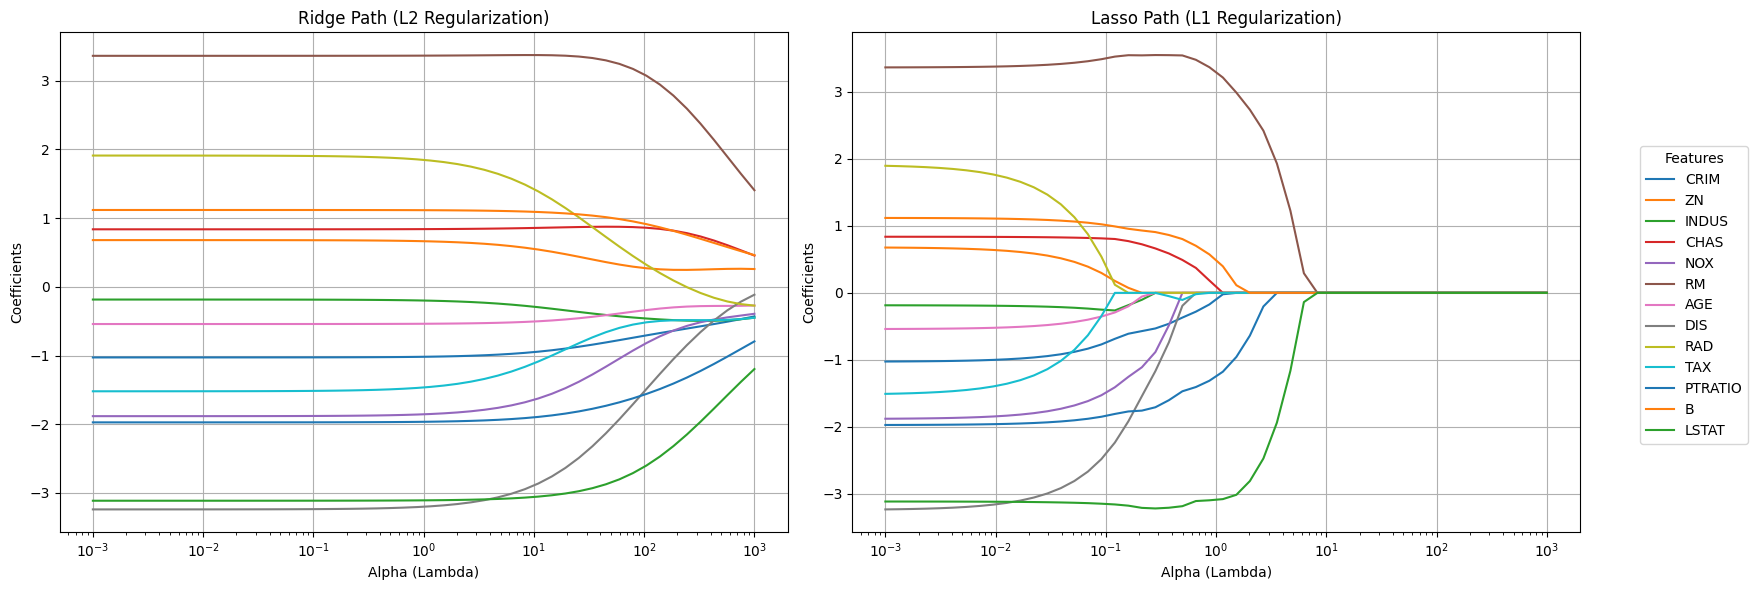

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso

# Prepare data (handle NaNs for the plot loop)
X_train_plot = np.nan_to_num(X_train, nan=np.nanmean(X_train, axis=0))
feature_names = X.columns

alphas = np.logspace(-3, 3, 50)
ridge_coefs = []
lasso_coefs = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_plot, y_train)
    ridge_coefs.append(ridge.coef_)

    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_plot, y_train)
    lasso_coefs.append(lasso.coef_)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Ridge Plot
ax[0].plot(alphas, ridge_coefs)
ax[0].set_xscale('log')
ax[0].set_title('Ridge Path (L2 Regularization)')
ax[0].set_xlabel('Alpha (Lambda)')
ax[0].set_ylabel('Coefficients')
ax[0].grid(True)

# Lasso Plot
ax[1].plot(alphas, lasso_coefs)
ax[1].set_xscale('log')
ax[1].set_title('Lasso Path (L1 Regularization)')
ax[1].set_xlabel('Alpha (Lambda)')
ax[1].set_ylabel('Coefficients')
ax[1].grid(True)

# Add a shared legend
fig.legend(feature_names, loc='center right', bbox_to_anchor=(1.1, 0.5), title="Features")
plt.tight_layout()
plt.show()

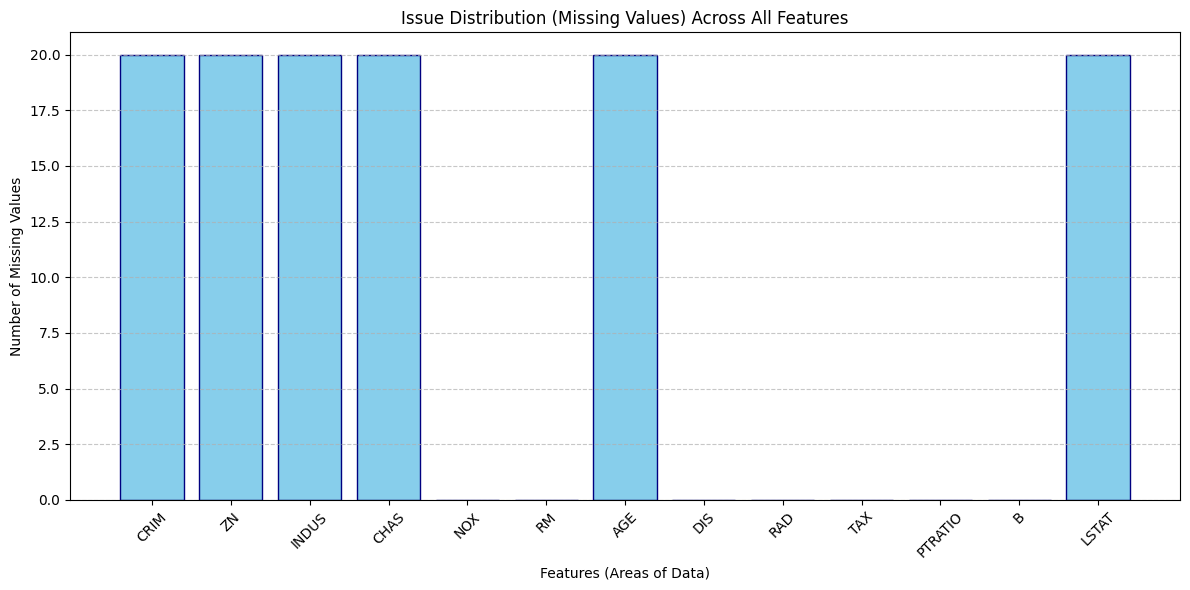

In [ ]:
import matplotlib.pyplot as plt

# Calculate the number of missing values (issues) for all features
missing_counts = data.drop(columns=['MEDV']).isnull().sum()
features = missing_counts.index
issue_values = missing_counts.values

plt.figure(figsize=(12, 6))
plt.bar(features, issue_values, color='skyblue', edgecolor='navy')

plt.xlabel("Features (Areas of Data)")
plt.ylabel("Number of Missing Values")
plt.title("Issue Distribution (Missing Values) Across All Features")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate percentage of missing values per feature
missing_percentage = (data.isnull().sum() / len(data)) * 100

# Filter to show only features with missing values for clarity, sorted by percentage
missing_info = pd.DataFrame({
    'Missing Values (Count)': data.isnull().sum(),
    'Percentage (%)': missing_percentage
}).sort_values(by='Percentage (%)', ascending=False)

print("Percentage of Missing Values per Feature:")
display(missing_info[missing_info['Missing Values (Count)'] > 0])

Percentage of Missing Values per Feature:


,Missing Values (Count),Percentage (%)
CRIM,20,3.952569
ZN,20,3.952569
INDUS,20,3.952569
CHAS,20,3.952569
LSTAT,20,3.952569
AGE,20,3.952569


### Why are the results so similar?

In this project, Linear, Ridge, and Lasso regression produced nearly identical results (~0.66 R%). This happened because:

1.  **Simple Data:** We have 506 rows but only 13 features. The models didn't need heavy 'penalties' to prevent overfitting because the dataset isn't complex enough to confuse them.
2.  **Weak Regularization:** Our tuning found very low 'Alpha' values (Lasso was near 0). When Alpha is low, Ridge and Lasso act almost exactly like standard Linear Regression.
3.  **Key Drivers:** Features like `RM` (rooms) and `LSTAT` (status) are so dominant that all three models quickly agreed on their importance, leading to the same predictions.

## Summary of Visualizations

Here is a breakdown of what each graph in this project represents:

1.  **Issue Distribution (Missing Values):** This bar chart identifies which data points were missing before we fixed them. It shows that features like `CRIM` and `ZN` had around 20 missing values (~4%), which we solved using mean imputation to keep all 506 rows for training.

2.  **Coefficient Comparison:** This line plot compares the weights assigned to each feature by the three models. Because the lines almost overlap, it proves that all three models (at their current settings) agree on which features are most important.

3.  **Ridge Path (L2 Regularization):** This shows 'Coefficient Shrinkage.' As we increase the penalty (Lambda), the lines move toward zero but never quite touch it. It demonstrates how Ridge keeps every feature but reduces its 'loudness' to prevent overfitting.

4.  **Lasso Path (L1 Regularization):** This shows 'Feature Selection.' Unlike Ridge, you can see lines hitting exactly zero. This reveals which features Lasso thinks are the least important, effectively 'turning them off' to simplify the model.